In [1]:
import gzip
import os

# Define paths for the files you want to inspect
target_files = ["../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz"]

for target_file in target_files:
    filename = os.path.basename(target_file)
    open_fn = gzip.open if target_file.endswith(".gz") else open

    first_5_lines = []
    total_lines = 0
    max_line_length = 0
    transcript_count = 0
    unique_genes = set()  # Set to track distinct gene IDs

    # Stream through the file to gather shape metrics and preview lines
    with open_fn(target_file, "rt") as handle:
        for line in handle:
            total_lines += 1
            clean_line = line.rstrip("\r\n")

            # Track Transcripts and Genes from header lines
            if line.startswith(">"):
                transcript_count += 1

                # Find and extract the 'gene:...' field
                for part in line.split():
                    if part.startswith("gene:"):
                        gene_id = part.split(":", 1)[1]
                        unique_genes.add(gene_id)
                        break

            # Store the first 5 lines
            if len(first_5_lines) < 5:
                first_5_lines.append(clean_line)

            # Track maximum line length (columns)
            if len(clean_line) > max_line_length:
                max_line_length = len(clean_line)

    # Print header, shape, metrics, and preview
    print(f"\n{'='*10} File: {filename} {'='*10}")
    print(
        f"Shape (Total Lines, Max Width): ({total_lines:,}, {max_line_length:,})"
    )
    print(f"Total Unique Transcripts: {transcript_count:,}")
    print(f"Total Unique Genes:       {len(unique_genes):,}")
    print("-" * 40)
    print("First 5 lines:")
    for line in first_5_lines:
        print(line)


========== File: Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz ==========
Shape (Total Lines, Max Width): (2,487,484, 357)
Total Unique Transcripts: 46,369
Total Unique Genes:       22,516
----------------------------------------
First 5 lines:
>ENSSSCT00000002339.4 cdna primary_assembly:Sscrofa11.1:AEMK02000555.1:34878:35168:1 gene:ENSSSCG00000035087.2 gene_biotype:TR_V_gene transcript_biotype:TR_V_gene
AAACAGCATGTGAATCAGAGCCACGAAGCCCTGAGCGTCCGAGAGGGAGACGGCTTGGTT
CTCAACTGCAGTTACACCGATAGCGCTATTTACTTCCTTCAGTGGTTTAGGCAGTATCCT
GGGAAAGGGCTTACTTCTCTGCTGTTAATTCAAGCGAACCAGGGAGAACAAATAAGTGGA
AGAATTAAAGCCTCATTGGATAAATCGTCAAGAAACAGTGTTTTCTACATTGCAGCATCT


# Inspecting dmd_splicing_matrix.csv

In [2]:
import pandas as pd

# Load the dataset and display the first 10 rows
# Note: Set index_col=0 if the first column contains exon/sample IDs rather than data
df = pd.read_csv('../data/processed/splicing_matrix.csv')
df.head(5)

,Transcript_ID,SRR32086846,SRR32086848,SRR32086850,SRR32086830,SRR32086832,SRR32086836,mean_TPM_WT,mean_TPM_DMD,fold_change,Gene_ID,IF_DMD,IF_WT
0,ENSSSCT00000019660,562.342977,459.901549,410.499472,444.081637,639.670911,448.405534,477.581333,510.719361,1.069386,ENSSSCG00000018065,1.0,1.0
1,ENSSSCT00000019664,353.471098,294.663002,317.050255,566.155260,472.968795,613.225246,321.728118,550.783100,1.711930,ENSSSCG00000018069,1.0,1.0
2,ENSSSCT00000019670,492.417681,485.020705,523.073988,1550.417623,1507.943906,1685.700721,500.170791,1581.354083,3.161585,ENSSSCG00000018075,1.0,1.0
3,ENSSSCT00000019673,1501.266861,1234.910440,1333.636342,3458.803243,3080.935513,3808.535173,1356.604548,3449.424643,2.542678,ENSSSCG00000018078,1.0,1.0
4,ENSSSCT00000019675,4750.440351,4860.873425,3835.651857,11075.955685,5320.894984,15203.767630,4482.321878,10533.539433,2.350016,ENSSSCG00000018080,1.0,1.0


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Load dataset
df = pd.read_csv('../data/processed/splicing_matrix.csv')

# Quick metric check
print("Dataset dimensions:", df.shape)
df[["mean_TPM_WT", "mean_TPM_DMD", "fold_change", "IF_DMD","IF_WT"]].describe()

Dataset dimensions: (19700, 13)


,mean_TPM_WT,mean_TPM_DMD,fold_change,IF_DMD,IF_WT
count,19700.000000,19700.000000,19700.000000,19700.000000,19700.000000
mean,50.757934,50.758485,17.467977,0.647588,0.651891
std,1462.642296,1467.472266,342.754402,0.410230,0.408809
min,0.000000,0.000000,0.000144,0.000000,0.000000
25%,0.283807,0.279550,0.529672,0.197894,0.206571
50%,1.209885,1.245912,1.055800,0.935540,0.941983
75%,4.978635,5.395528,2.005854,0.999993,0.999993
max,143393.188954,146753.071718,41445.132900,1.000000,1.000000


In [4]:
# Check total rows vs unique Transcript IDs
total_rows = len(df)
unique_transcripts = df["Transcript_ID"].nunique()

print(f"Total rows: {total_rows}")
print(f"Unique Transcripts: {unique_transcripts}")

# Check how many unique GENES these transcripts belong to
unique_genes = df["Gene_ID"].nunique()
print(f"Belonging to {unique_genes} unique genes.")

Total rows: 19700
Unique Transcripts: 19700
Belonging to 13473 unique genes.


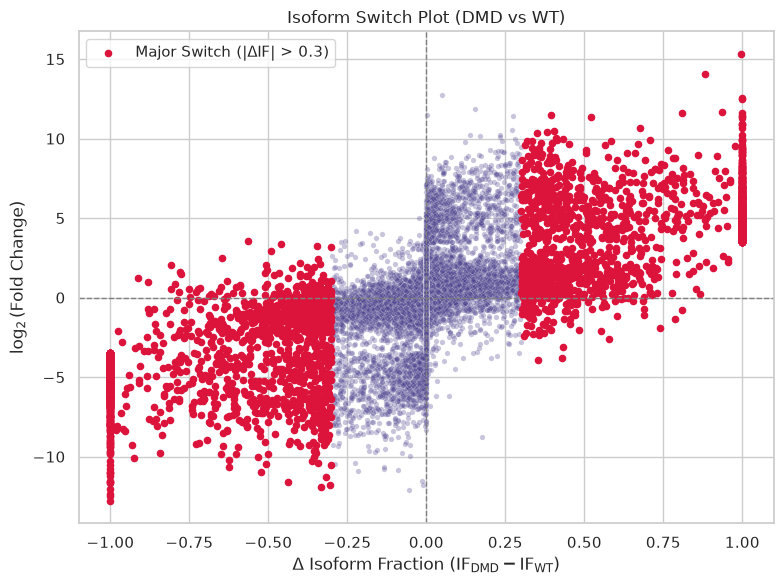

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Feature engineering
df["delta_IF"] = df["IF_DMD"] - df["IF_WT"]
df["log2_FC"] = np.log2(df["fold_change"])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="delta_IF",
    y="log2_FC",
    alpha=0.3,
    s=15,
    color="darkslateblue"
)

# Highlight significant isoform switches (|delta_IF| > 0.3)
switches = df[df["delta_IF"].abs() > 0.3]
plt.scatter(switches["delta_IF"], switches["log2_FC"], color="crimson", s=20, label="Major Switch (|ΔIF| > 0.3)")

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Isoform Switch Plot (DMD vs WT)")
plt.xlabel(r"$\Delta$ Isoform Fraction ($\text{IF}_{\text{DMD}} - \text{IF}_{\text{WT}}$)")
plt.ylabel(r"$\log_2(\text{Fold Change})$")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

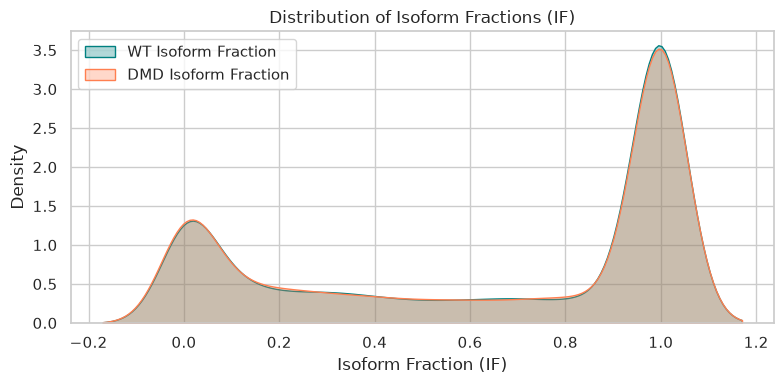

In [6]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df["IF_WT"], label="WT Isoform Fraction", color="teal", fill=True, alpha=0.3)
sns.kdeplot(df["IF_DMD"], label="DMD Isoform Fraction", color="coral", fill=True, alpha=0.3)

plt.title("Distribution of Isoform Fractions (IF)")
plt.xlabel("Isoform Fraction (IF)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Extracting Gene Names From Raw Data

In [11]:
import gzip
from pathlib import Path
import pandas as pd

# Load existing splicing matrix
df = pd.read_csv("../data/processed/splicing_matrix.csv")

# Extract Gene_ID -> Gene_Name map from FASTA
fasta_path = Path("../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz")
gene_map = {}

with gzip.open(fasta_path, "rt") as handle:
    for line in handle:
        if line.startswith(">"):
            parts = line.strip().split()
            gene_id, gene_name = None, None

            for part in parts:
                if part.startswith("gene:"):
                    gene_id = part.split(":")[1].split(".")[0]
                elif part.startswith("gene_symbol:"):
                    gene_name = part.split(":")[1]

            if gene_id and gene_name:
                gene_map[gene_id] = gene_name

# Map names and fall back to Gene_ID if no symbol exists
df["Gene_Name"] = df["Gene_ID"].map(gene_map).fillna(df["Gene_ID"])

# Save updated CSV
df.to_csv("../data/processed/splicing_matrix.csv", index=False)
print(f"Mapped {df['Gene_Name'].nunique()} unique gene names.")
df[["Transcript_ID", "Gene_ID", "Gene_Name", "IF_DMD","IF_WT"]].head()

Mapped 13473 unique gene names.


,Transcript_ID,Gene_ID,Gene_Name,IF_DMD,IF_WT
0,ENSSSCT00000019660,ENSSSCG00000018065,ND1,1.0,1.0
1,ENSSSCT00000019664,ENSSSCG00000018069,ND2,1.0,1.0
2,ENSSSCT00000019670,ENSSSCG00000018075,COX1,1.0,1.0
3,ENSSSCT00000019673,ENSSSCG00000018078,COX2,1.0,1.0
4,ENSSSCT00000019675,ENSSSCG00000018080,ATP8,1.0,1.0


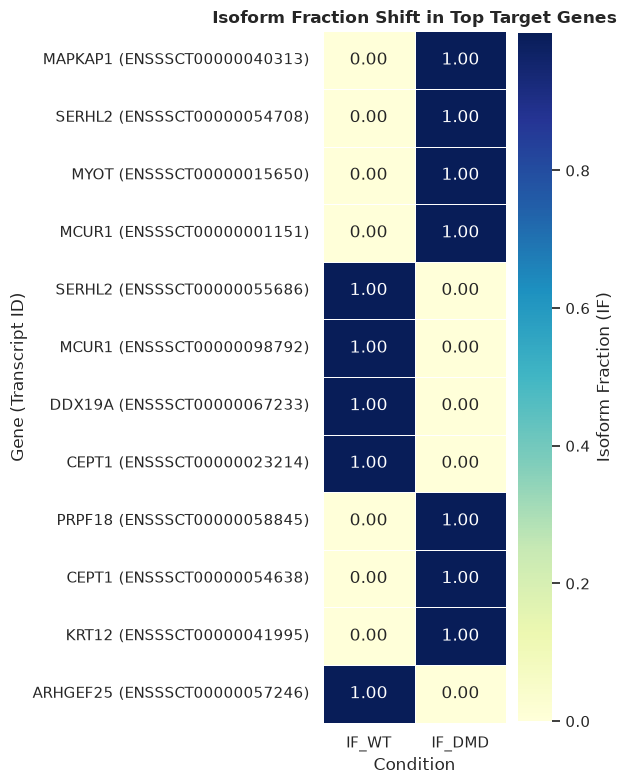

In [20]:
# Pick top 8 multi-isoform genes with highest isoform shifts
multi_genes = df['Gene_ID'].value_counts()
multi_genes = multi_genes[multi_genes >= 2].index

candidate_txs = (
    df[(df['Gene_ID'].isin(multi_genes)) & (df['max_TPM'] >= 1.0)]
    .sort_values(by="delta_IF", key=abs, ascending=False)
    .head(12)
)

# Prepare label: "Gene_Name - Transcript_ID"
candidate_txs["Label"] = candidate_txs["Gene_Name"] + " (" + candidate_txs["Transcript_ID"] + ")"
heatmap_data = candidate_txs.set_index("Label")[["IF_WT", "IF_DMD"]]

plt.figure(figsize=(6, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Isoform Fraction (IF)'},
    linewidths=0.5
)

plt.title("Isoform Fraction Shift in Top Target Genes", fontsize=12, fontweight="bold")
plt.ylabel("Gene (Transcript ID)")
plt.xlabel("Condition")
plt.tight_layout()
plt.show()

In [31]:
import gzip
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# --- 1. Jupyter Path Fix ---
# Handle project path whether your notebook is in root or a 'notebooks/' folder
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import project configurations
from config import (
    DMD_RUNS,
    PROCESSED_DIR,
    QUANT_DIR,
    TARGET_RUNS,
    TRANSCRIPTOME_FASTA,
    WT_RUNS,
)


# --- 2. Helper Functions ---
def get_tx2gene_map(fasta_path: Path) -> dict:
    """Parses Ensembl cDNA headers to map Transcript IDs to Gene IDs."""
    tx2gene = {}
    if not fasta_path.exists():
        print(f"[!] Warning: cDNA reference missing at {fasta_path}.")
        return tx2gene

    print(f"[+] Extracting Tx-to-Gene map from {fasta_path.name}...")
    with gzip.open(fasta_path, "rt") as handle:
        for line in handle:
            if line.startswith(">"):
                parts = line.strip().split()
                tx_id = parts[0][1:].split(".")[0]

                gene_id = None
                for part in parts:
                    if part.startswith("gene:"):
                        gene_id = part.split(":")[1].split(".")[0]
                        break

                if gene_id:
                    tx2gene[tx_id] = gene_id

    print(f"[✓] Mapped {len(tx2gene):,} transcripts to parent genes.")
    return tx2gene


def parse_and_aggregate_quants() -> pd.DataFrame:
    """Merges all 6 quant.sf files, calculates per-replicate IFs, group means,

    delta_IF, Welch's t-test p-values, and Benjamini-Hochberg FDR.
    """
    print("[+] Merging sample quantifications into master splicing matrix...")

    dataframes = {}

    # Read TPM from all 6 quant.sf files
    for sra_id in TARGET_RUNS:
        quant_file = QUANT_DIR / sra_id / "quant.sf"
        if not quant_file.exists():
            print(f"[X] Quant file missing for {sra_id} at {quant_file}.")
            return None

        print(f"  -> Loading {sra_id}...")
        df = pd.read_csv(quant_file, sep="\t", usecols=["Name", "TPM"])
        df["Transcript_ID"] = df["Name"].str.split(".").str[0]
        dataframes[sra_id] = df.set_index("Transcript_ID")["TPM"]

    master_df = pd.DataFrame(dataframes)
    print(f"[✓] Matrix created: {master_df.shape[0]:,} transcripts x {master_df.shape[1]} samples.")

    # Map Transcript_ID to Gene_ID
    tx2gene = get_tx2gene_map(TRANSCRIPTOME_FASTA)
    if not tx2gene:
        print("[!] Error: cDNA FASTA not found or mapping failed.")
        return None

    master_df["Gene_ID"] = master_df.index.map(tx2gene)
    master_df = master_df.dropna(subset=["Gene_ID"])

    # Calculate Isoform Fraction (IF) PER REPLICATE
    print("[+] Calculating per-replicate Isoform Fractions (IF)...")
    if_cols_wt = []
    if_cols_dmd = []

    for sra_id in TARGET_RUNS:
        gene_totals = master_df.groupby("Gene_ID")[sra_id].transform("sum")
        if_col_name = f"IF_{sra_id}"
        master_df[if_col_name] = master_df[sra_id] / (gene_totals + 1e-5)

        if sra_id in WT_RUNS:
            if_cols_wt.append(if_col_name)
        elif sra_id in DMD_RUNS:
            if_cols_dmd.append(if_col_name)

    # Compute Group Means
    master_df["mean_TPM_WT"] = master_df[WT_RUNS].mean(axis=1)
    master_df["mean_TPM_DMD"] = master_df[DMD_RUNS].mean(axis=1)

    master_df["mean_IF_WT"] = master_df[if_cols_wt].mean(axis=1)
    master_df["mean_IF_DMD"] = master_df[if_cols_dmd].mean(axis=1)

    master_df["delta_IF"] = master_df["mean_IF_DMD"] - master_df["mean_IF_WT"]
    master_df["fold_change"] = (master_df["mean_TPM_DMD"] + 0.01) / (master_df["mean_TPM_WT"] + 0.01)

    # Welch's t-test across 3 WT vs 3 DMD replicates
    print("[+] Running Welch's t-test across replicates...")
    wt_if_vals = master_df[if_cols_wt].values
    dmd_if_vals = master_df[if_cols_dmd].values

    _, p_vals = stats.ttest_ind(dmd_if_vals, wt_if_vals, axis=1, equal_var=False)
    master_df["p_value"] = np.nan_to_num(p_vals, nan=1.0)

    # Benjamini-Hochberg FDR correction
    _, fdr_vals, _, _ = multipletests(master_df["p_value"], method="fdr_bh")
    master_df["FDR"] = fdr_vals

    # Filter out unexpressed transcripts (> 0.1 TPM in at least one condition)
    filtered_df = master_df[
        (master_df["mean_TPM_WT"] > 0.1) | (master_df["mean_TPM_DMD"] > 0.1)
    ].reset_index()

    # Save output CSV
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    output_csv = PROCESSED_DIR / "splicing_matrix.csv"
    filtered_df.to_csv(output_csv, index=False)

    print(f"\n[✓] DONE! Splicing matrix saved ({len(filtered_df):,} transcripts) to:\n    {output_csv}")
    return filtered_df


# --- 3. Execute in Notebook ---
df_splicing = parse_and_aggregate_quants()

# Preview top statistically significant isoform switches (FDR < 0.05 and |delta_IF| > 0.2)
if df_splicing is not None:
    display(
        df_splicing[
            (df_splicing["FDR"] < 0.05) & (df_splicing["delta_IF"].abs() > 0.2)
        ]
        .sort_values(by="FDR")
        .head(10)
    )

[+] Merging sample quantifications into master splicing matrix...
  -> Loading SRR32086846...
  -> Loading SRR32086848...
  -> Loading SRR32086850...
  -> Loading SRR32086830...
  -> Loading SRR32086832...
  -> Loading SRR32086836...
[✓] Matrix created: 46,295 transcripts x 6 samples.
[+] Extracting Tx-to-Gene map from Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz...
[✓] Mapped 46,369 transcripts to parent genes.
[+] Calculating per-replicate Isoform Fractions (IF)...
[+] Running Welch's t-test across replicates...

[✓] DONE! Splicing matrix saved (19,700 transcripts) to:
    /home/w/EVA/data/processed/splicing_matrix.csv


,Transcript_ID,SRR32086846,SRR32086848,SRR32086850,SRR32086830,SRR32086832,SRR32086836,Gene_ID,IF_SRR32086846,IF_SRR32086848,...,IF_SRR32086832,IF_SRR32086836,mean_TPM_WT,mean_TPM_DMD,mean_IF_WT,mean_IF_DMD,delta_IF,fold_change,p_value,FDR
1613,ENSSSCT00000015650,0.000000,0.000000,0.000000,8.953436,10.058274,10.226136,ENSSSCG00000014324,0.000000,0.000000,...,0.999999,0.999999,0.000000,9.745949,0.000000,0.999999,0.999999,975.594867,1.924408e-15,5.519113e-11
3693,ENSSSCT00000046003,31.926938,45.947911,131.048202,0.000000,0.000000,0.000000,ENSSSCG00000031292,1.000000,1.000000,...,0.000000,0.000000,69.641017,0.000000,1.000000,0.000000,-1.000000,0.000144,4.735236e-15,5.519113e-11
8795,ENSSSCT00000042940,1.804804,1.829172,1.754103,0.000000,0.000000,0.000000,ENSSSCG00000034510,0.999994,0.999995,...,0.000000,0.000000,1.796026,0.000000,0.999994,0.000000,-0.999994,0.005537,4.768647e-15,5.519113e-11
17702,ENSSSCT00000040313,0.000000,0.000000,0.000000,17.206845,12.973962,18.069473,ENSSSCG00000029169,0.000000,0.000000,...,0.999999,0.999999,0.000000,16.083427,0.000000,0.999999,0.999999,1609.342667,4.664721e-15,5.519113e-11
7071,ENSSSCT00000054708,0.000000,0.000000,0.000000,14.501626,10.242768,11.734252,ENSSSCG00000034350,0.000000,0.000000,...,0.999999,0.999999,0.000000,12.159549,0.000000,0.999999,0.999999,1216.954867,6.891971e-15,6.381276e-11
2247,ENSSSCT00000001151,0.000000,0.000000,0.000000,7.681942,11.415665,8.601302,ENSSSCG00000054763,0.000000,0.000000,...,0.999999,0.999999,0.000000,9.232970,0.000000,0.999999,0.999999,924.296967,1.571050e-14,1.042775e-10
16499,ENSSSCT00000013274,5.807711,7.144047,7.647466,0.000000,0.000000,0.000000,ENSSSCG00000012135,0.999998,0.999999,...,0.000000,0.000000,6.866408,0.000000,0.999999,0.000000,-0.999999,0.001454,1.576720e-14,1.042775e-10
7070,ENSSSCT00000055686,6.157081,6.409784,4.943398,0.000000,0.000000,0.000000,ENSSSCG00000034350,0.999998,0.999998,...,0.000000,0.000000,5.836754,0.000000,0.999998,0.000000,-0.999998,0.001710,2.095962e-14,1.109798e-10
12375,ENSSSCT00000104525,0.000000,0.000000,0.000000,34.802906,122.805000,17.025802,ENSSSCG00000063541,0.000000,0.000000,...,1.000000,0.999999,0.000000,58.211236,0.000000,1.000000,1.000000,5822.123600,2.157507e-14,1.109798e-10
13013,ENSSSCT00000033719,0.000000,0.000000,0.000000,4.662969,3.882827,3.405016,ENSSSCG00000006059,0.000000,0.000000,...,0.999997,0.999997,0.000000,3.983604,0.000000,0.999997,0.999997,399.360400,5.244379e-14,2.427885e-10


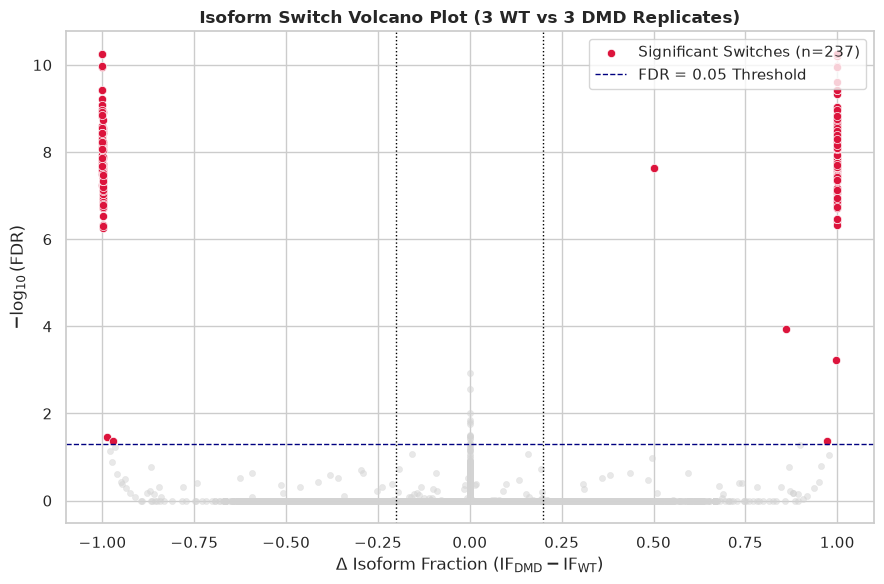

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load updated matrix
df = pd.read_csv("../data/processed/splicing_matrix.csv")

# Compute -log10(FDR) for plotting
df["minus_log10_FDR"] = -np.log10(df["FDR"] + 1e-15)

plt.figure(figsize=(9, 6))

# Background points (non-significant)
sns.scatterplot(
    data=df,
    x="delta_IF",
    y="minus_log10_FDR",
    color="lightgray",
    alpha=0.5,
    s=20,
    edgecolor=None,
)

# Highlight statistically significant switches
sig_mask = (df["FDR"] < 0.05) & (df["delta_IF"].abs() > 0.2)
sig_df = df[sig_mask]

sns.scatterplot(
    data=sig_df,
    x="delta_IF",
    y="minus_log10_FDR",
    color="crimson",
    s=35,
    label=f"Significant Switches (n={len(sig_df):,})",
)

# Threshold lines
plt.axhline(
    -np.log10(0.05),
    color="navy",
    linestyle="--",
    linewidth=1,
    label="FDR = 0.05 Threshold",
)
plt.axvline(0.2, color="black", linestyle=":", linewidth=1)
plt.axvline(-0.2, color="black", linestyle=":", linewidth=1)

plt.title(
    "Isoform Switch Volcano Plot (3 WT vs 3 DMD Replicates)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(
    r"$\Delta$ Isoform Fraction ($\text{IF}_{\text{DMD}} - \text{IF}_{\text{WT}}$)"
)
plt.ylabel(r"$-\log_{10}(\text{FDR})$")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

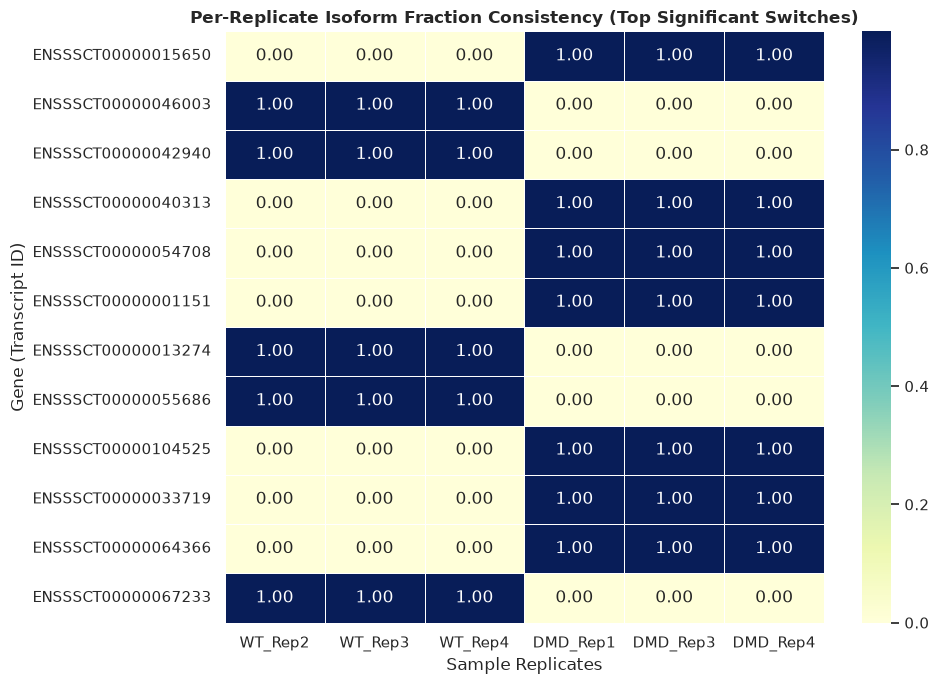

In [33]:
# Identify replicate IF columns
from config import DMD_RUNS, WT_RUNS

wt_if_cols = [f"IF_{sra}" for sra in WT_RUNS]
dmd_if_cols = [f"IF_{sra}" for sra in DMD_RUNS]
all_if_cols = wt_if_cols + dmd_if_cols

# Filter for top 12 statistically significant switches sorted by FDR
top_sig = (
    df[(df["FDR"] < 0.05) & (df["delta_IF"].abs() > 0.2)]
    .sort_values(by="FDR")
    .head(12)
    .copy()
)

# Create display label
if "Gene_Name" in top_sig.columns:
    top_sig["Label"] = (
        top_sig["Gene_Name"] + " (" + top_sig["Transcript_ID"] + ")"
    )
else:
    top_sig["Label"] = top_sig["Transcript_ID"]

heatmap_df = top_sig.set_index("Label")[all_if_cols]

# Plot Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    xticklabels=[
        "WT_Rep2",
        "WT_Rep3",
        "WT_Rep4",
        "DMD_Rep1",
        "DMD_Rep3",
        "DMD_Rep4",
    ],
)

plt.title(
    "Per-Replicate Isoform Fraction Consistency (Top Significant Switches)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Sample Replicates")
plt.ylabel("Gene (Transcript ID)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_50705/255197657.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


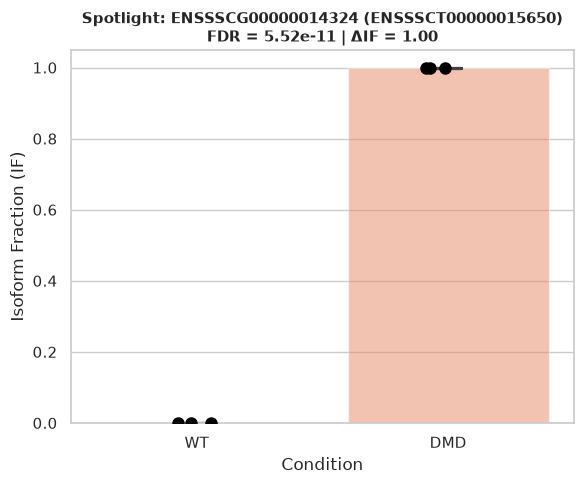

In [34]:
# Select the single most statistically significant transcript
top_tx = (
    df[(df["FDR"] < 0.05) & (df["delta_IF"].abs() > 0.2)]
    .sort_values(by="FDR")
    .iloc[0]
)

# Reshape data into long format for plotting
wt_vals = [top_tx[f"IF_{sra}"] for sra in WT_RUNS]
dmd_vals = [top_tx[f"IF_{sra}"] for sra in DMD_RUNS]

spotlight_df = pd.DataFrame(
    {
        "Condition": ["WT"] * 3 + ["DMD"] * 3,
        "Isoform_Fraction": wt_vals + dmd_vals,
        "Replicate": WT_RUNS + DMD_RUNS,
    }
)

plt.figure(figsize=(6, 5))

# Group mean bar chart with error bars
sns.barplot(
    data=spotlight_df,
    x="Condition",
    y="Isoform_Fraction",
    palette={"WT": "teal", "DMD": "coral"},
    alpha=0.5,
    capsize=0.1,
    errorbar="se",
)

# Individual sample replicate points overlay
sns.stripplot(
    data=spotlight_df,
    x="Condition",
    y="Isoform_Fraction",
    color="black",
    size=9,
    jitter=0.1,
)

gene_label = (
    top_tx.get("Gene_Name", top_tx["Gene_ID"])
    if pd.notna(top_tx.get("Gene_Name"))
    else top_tx["Gene_ID"]
)

plt.title(
    f"Spotlight: {gene_label} ({top_tx['Transcript_ID']})\nFDR = {top_tx['FDR']:.2e} | ΔIF = {top_tx['delta_IF']:.2f}",
    fontsize=11,
    fontweight="bold",
)
plt.ylabel("Isoform Fraction (IF)")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

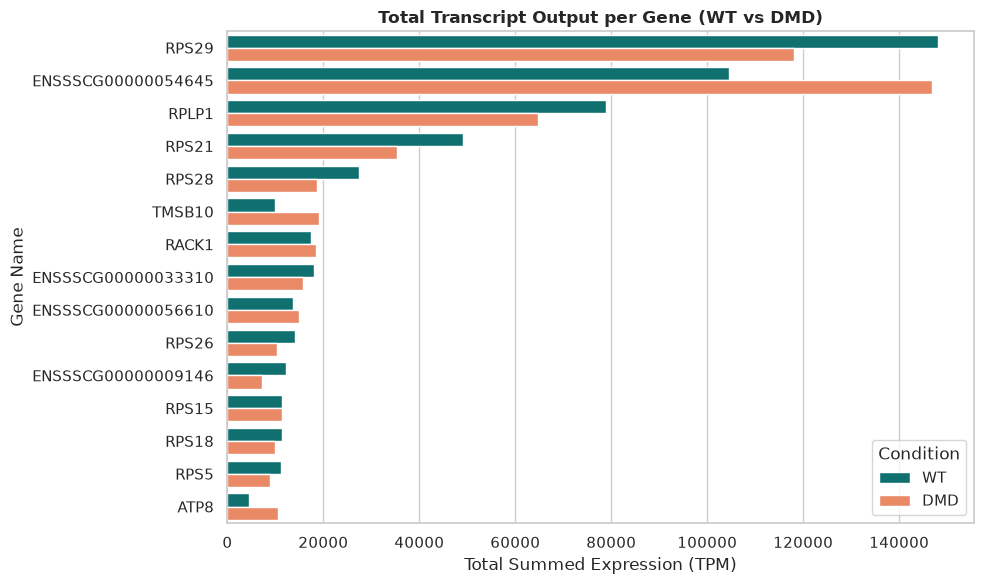

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load data
df = pd.read_csv("../data/processed/splicing_matrix.csv")

# 1. Aggregate transcript TPMs to get Total Gene Output per condition
gene_summary = (
    df.groupby(["Gene_ID", "Gene_Name"])[["mean_TPM_WT", "mean_TPM_DMD"]]
    .sum()
    .reset_index()
)

# Compute max total TPM to filter top expressed genes
gene_summary["max_total_TPM"] = gene_summary[["mean_TPM_WT", "mean_TPM_DMD"]].max(axis=1)

# Pick top 15 most highly expressed genes (or top switching genes)
top_genes = gene_summary.nlargest(15, "max_total_TPM")

# 2. Reshape (Melt) for color-coded plotting
plot_df = top_genes.melt(
    id_vars=["Gene_Name"],
    value_vars=["mean_TPM_WT", "mean_TPM_DMD"],
    var_name="Condition",
    value_name="Total_Gene_TPM",
)
plot_df["Condition"] = plot_df["Condition"].map(
    {"mean_TPM_WT": "WT", "mean_TPM_DMD": "DMD"}
)

# 3. Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Total_Gene_TPM",
    y="Gene_Name",
    hue="Condition",
    palette={"WT": "teal", "DMD": "coral"},
)

plt.title("Total Transcript Output per Gene (WT vs DMD)", fontsize=12, fontweight="bold")
plt.xlabel("Total Summed Expression (TPM)")
plt.ylabel("Gene Name")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

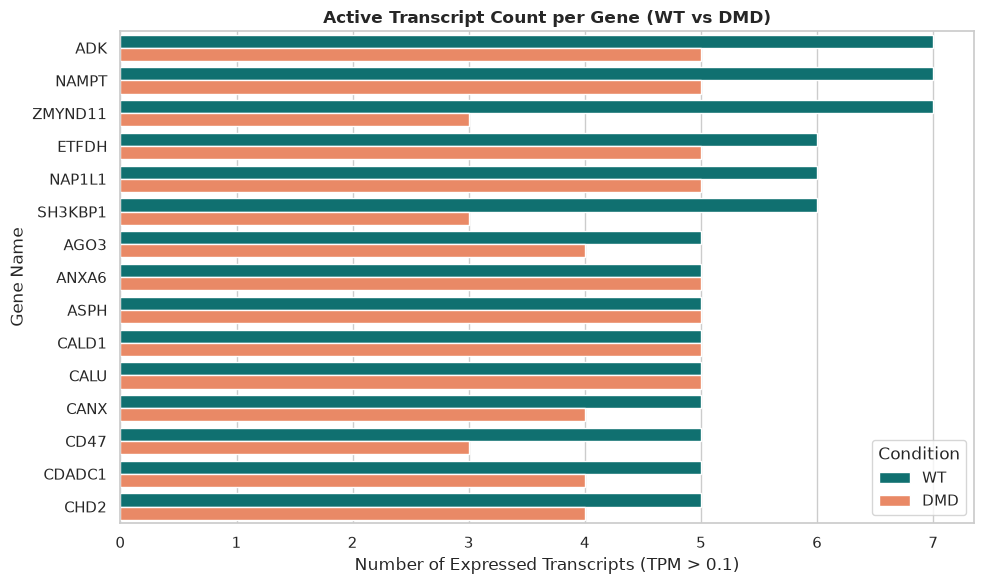

In [23]:
# Count how many transcripts pass TPM > 0.1 threshold in each condition
active_counts = (
    df.groupby("Gene_Name")
    .agg(
        Active_Transcripts_WT=("mean_TPM_WT", lambda x: (x > 0.1).sum()),
        Active_Transcripts_DMD=("mean_TPM_DMD", lambda x: (x > 0.1).sum()),
    )
    .reset_index()
)

# Filter for top multi-isoform genes
top_multi = active_counts.nlargest(15, "Active_Transcripts_WT")

# Reshape & Plot
plot_counts = top_multi.melt(
    id_vars=["Gene_Name"],
    value_vars=["Active_Transcripts_WT", "Active_Transcripts_DMD"],
    var_name="Condition",
    value_name="Transcript_Count",
)
plot_counts["Condition"] = plot_counts["Condition"].map(
    {"Active_Transcripts_WT": "WT", "Active_Transcripts_DMD": "DMD"}
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_counts,
    x="Transcript_Count",
    y="Gene_Name",
    hue="Condition",
    palette={"WT": "teal", "DMD": "coral"},
)
plt.title("Active Transcript Count per Gene (WT vs DMD)", fontsize=12, fontweight="bold")
plt.xlabel("Number of Expressed Transcripts (TPM > 0.1)")
plt.ylabel("Gene Name")
plt.tight_layout()
plt.show()

# Obtaining Gene information per id 

In [8]:
"""import gzip
from pathlib import Path
import mygene
import pandas as pd

# Step 1: Read unique Gene_IDs from the splicing matrix
print("[1/4] Extracting unique Gene IDs from matrix...")
matrix_path = Path("../data/processed/splicing_matrix.csv")
df = pd.read_csv(matrix_path, usecols=["Gene_ID"])
unique_gene_ids = df["Gene_ID"].dropna().unique().tolist()

# Step 2: Extract Gene_ID -> Gene_Name map from FASTA
fasta_path = Path("../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz")
gene_map = {}

print(f"[2/4] Parsing FASTA ({fasta_path.name})... Please wait ~30-60 seconds.")
line_count = 0
with gzip.open(fasta_path, "rt") as handle:
    for line in handle:
        line_count += 1
        if line_count % 1000000 == 0:
            print(f"      ...processed {line_count:,} lines...")

        if line.startswith(">"):
            parts = line.strip().split()
            gene_id, gene_name = None, None

            for part in parts:
                if part.startswith("gene:"):
                    gene_id = part.split(":")[1].split(".")[0]
                elif part.startswith("gene_symbol:"):
                    gene_name = part.split(":")[1]

            if gene_id and gene_name:
                gene_map[gene_id] = gene_name

print(f"      [✓] Mapped {len(gene_map):,} gene IDs from FASTA.")

# Create base mapping DataFrame for dataset genes
mapping_df = pd.DataFrame({"Gene_ID": unique_gene_ids})
mapping_df["Gene_Name"] = mapping_df["Gene_ID"].map(gene_map).fillna(
    mapping_df["Gene_ID"]
)

# Step 3: Query MyGene using built-in batching
unique_genes_to_query = mapping_df["Gene_Name"].unique().tolist()
print(
    f"[3/4] Querying MyGene.info for {len(unique_genes_to_query):,} unique genes..."
)

mg = mygene.MyGeneInfo()
results = mg.querymany(
    unique_genes_to_query,
    scopes=["symbol", "ensembl.gene"],
    fields=["name", "summary", "go.BP"],
    species="pig,human",
    step=1000,
    as_dataframe=False,
)

# Step 4: Parse MyGene API responses & Save Mapping CSV
print("[4/4] Parsing functional terms & saving standalone gene mapping file...")
annotations = {}
for res in results:
    query_key = res.get("query")
    if not query_key or query_key in annotations:
        continue

    full_description = res.get("name", None)
    summary = res.get("summary", None)

    go_bp_list = []
    go_data = (
        res.get("go", {}).get("BP", [])
        if isinstance(res.get("go"), dict)
        else []
    )

    if isinstance(go_data, dict):
        go_data = [go_data]

    for term in go_data:
        if isinstance(term, dict) and "term" in term:
            go_bp_list.append(term["term"])

    go_bp_str = "; ".join(list(set(go_bp_list))[:5]) if go_bp_list else None

    annotations[query_key] = {
        "Gene_Description": full_description,
        "Gene_Summary": summary,
        "GO_Biological_Process": go_bp_str,
    }

anno_df = pd.DataFrame.from_dict(annotations, orient="index").reset_index()
anno_df.rename(columns={"index": "Gene_Name"}, inplace=True)

# Merge annotations into mapping lookup table
mapping_full = mapping_df.merge(anno_df, on="Gene_Name", how="left")

# Save dedicated gene mapping CSV
map_output_path = Path("../data/processed/gene_id_to_name_mapping.csv")
mapping_full.to_csv(map_output_path, index=False)

print(f"[✓] Done! Gene lookup table saved to: {map_output_path}")"""

[1/4] Extracting unique Gene IDs from matrix...
[2/4] Parsing FASTA (Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz)... Please wait ~30-60 seconds.
      ...processed 1,000,000 lines...
      ...processed 2,000,000 lines...
      [✓] Mapped 15,815 gene IDs from FASTA.
[3/4] Querying MyGene.info for 13,473 unique genes...


11282 input query terms found dup hits:	[('SH3YL1', 2), ('FAM110C', 2), ('EDIL3', 2), ('COX7C', 2), ('CETN3', 2), ('MBLAC2', 2), ('LYSMD3', 
126 input query terms found no hit:	['C12orf29', 'C12orf50', 'MFSD3', 'ENSSSCG00000005901', 'ENSSSCG00000053412', 'MDM1', 'BVES', 'MFSD9


[4/4] Parsing functional terms & saving standalone gene mapping file...
[✓] Done! Gene lookup table saved to: ../data/processed/gene_id_to_name_mapping.csv
